In [ ]:
import pandas as pd

# URLs for Patient and Sample level data
patient_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/msk_impact_2017/data_clinical_patient.txt"
sample_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/msk_impact_2017/data_clinical_sample.txt"

# Load both datasets
df_patient = pd.read_csv(patient_url, sep="\t", comment="#")
df_sample = pd.read_csv(sample_url, sep="\t", comment="#")

# Merge on PATIENT_ID
df_msk = pd.merge(df_patient, df_sample, on="PATIENT_ID")

print(f"Dataset shape: {df_msk.shape}")
# df_msk.head()

Combined dataset shape: (10945, 23)


,PATIENT_ID,SEX,VITAL_STATUS,SMOKING_HISTORY,OS_MONTHS,OS_STATUS,SAMPLE_ID,SAMPLE_COLLECTION_SOURCE,SPECIMEN_PRESERVATION_TYPE,SPECIMEN_TYPE,DNA_INPUT,SAMPLE_COVERAGE,TUMOR_PURITY,MATCHED_STATUS,SAMPLE_TYPE,PRIMARY_SITE,METASTATIC_SITE,SAMPLE_CLASS,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,P-0000004,Female,ALIVE,Unknown,NaN,0:LIVING,P-0000004-T01-IM3,Outside,FFPE,Biopsy,250.0,428.0,50.0,Matched,Primary,Breast,Not Applicable,Tumor,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Matched,17.746485
1,P-0000015,Female,DECEASED,Never,NaN,1:DECEASED,P-0000015-T01-IM3,In-House,FFPE,Biopsy,198.0,281.0,40.0,Matched,Metastasis,Breast,Liver,Tumor,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Matched,7.764087
2,P-0000023,Male,DECEASED,Never,8.71,1:DECEASED,P-0000023-T01-IM3,In-House,FFPE,Biopsy,250.0,454.0,30.0,Matched,Primary,Peritoneum,Not Applicable,Tumor,PEMESO,Mesothelioma,Peritoneal Mesothelioma,Matched,5.545777
3,P-0000024,Female,ALIVE,Prev/Curr Smoker,36.75,0:LIVING,P-0000024-T01-IM3,In-House,FFPE,Resection,250.0,1016.0,40.0,Matched,Metastasis,Uterus,Lung,Tumor,UEC,Endometrial Cancer,Uterine Endometrioid Carcinoma,Matched,6.654932
4,P-0000025,Female,ALIVE,Never,8.81,0:LIVING,P-0000025-T02-IM5,In-House,FFPE,Biopsy,250.0,1147.0,30.0,Matched,Metastasis,Uterus,Peritoneum,Tumor,USC,Endometrial Cancer,Uterine Serous Carcinoma/Uterine Papillary Ser...,Matched,1.957439


In [ ]:
import io
import tarfile
import requests
import pandas as pd

# Download MSK-IMPACT 2017 study archive from cBioPortal
archive_url = "https://datahub.assets.cbioportal.org/msk_impact_2017.tar.gz"

response = requests.get(archive_url)

with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz") as tar:
    for member in tar.getmembers():
        if member.name.endswith("data_mutations.txt"):
            f = tar.extractfile(member)
            mut_df = pd.read_csv(f, sep="\t", comment="#", low_memory=False)
            
print(f"Loaded mutation dataset shape: {mut_df.shape}")

pd.set_option('display.max_columns', None)
display(mut_df.head(3))

print(mut_df.columns.tolist())

Loaded mutation dataset shape: (78220, 46)


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,t_ref_count,t_alt_count,n_ref_count,n_alt_count,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Hotspot,cDNA_change
0,SPEN,NaN,NaN,GRCh37,1,16265908,16265908,+,missense_variant,Missense_Mutation,SNP,A,A,T,NaN,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400,73,NaN,NaN,ENST00000375759.3:c.10981A>T,p.Ile3661Phe,p.I3661F,ENST00000375759,NM_015001.2,3661.0,Att/Ttt,0,c.10981A>T
1,ALK,NaN,NaN,GRCh37,2,29543736,29543736,+,missense_variant,Missense_Mutation,SNP,A,A,G,NaN,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180,13,NaN,NaN,ENST00000389048.3:c.1427T>C,p.Val476Ala,p.V476A,ENST00000389048,NM_004304.4,476.0,gTg/gCg,0,c.1427T>C
2,PDCD1,NaN,NaN,GRCh37,2,242793433,242793433,+,missense_variant,Missense_Mutation,SNP,G,G,A,NaN,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225,15,NaN,NaN,ENST00000334409.5:c.644C>T,p.Ala215Val,p.A215V,ENST00000334409,NM_005018.2,215.0,gCc/gTc,0,c.644C>T


['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS', 'dbSNP_Val_Status', 'Tumor_Sample_Barcode', 'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1', 'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1', 'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1', 'Match_Norm_Validation_Allele2', 'Verification_Status', 'Validation_Status', 'Mutation_Status', 'Sequencing_Phase', 'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File', 'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq', 'Protein_position', 'Codons', 'Hotspot', 'cDNA_change']


In [ ]:
# Count one mutation per gene per patient
unique_muts = mut_df[['Tumor_Sample_Barcode', 'Hugo_Symbol']].drop_duplicates()

# Count how many unique patients have a mutation for each gene to find top 10
top_10_genes = unique_muts['Hugo_Symbol'].value_counts().head(10).index.tolist()

print(top_10_genes)

['TP53', 'KRAS', 'TERT', 'PIK3CA', 'APC', 'ARID1A', 'MLL2', 'PTEN', 'MLL3', 'EGFR']


In [117]:
# Filter the mutation dataframe to only include rows for these top 10 genes
filtered_muts = mut_df[mut_df['Hugo_Symbol'].isin(top_10_genes_list)]
print(f"Filtered mutation dataset shape: {filtered_muts.shape}")



Filtered mutation dataset shape: (16028, 46)


In [ ]:
# Transform mutation data into one patient per row, one gene per column format (binary mutation matrix)
# (1 = mutated, 0 = wild-type)
# Rows = samples, columns = genes
gene_matrix = pd.crosstab(filtered_muts['Tumor_Sample_Barcode'], filtered_muts['Hugo_Symbol'])
gene_matrix = (gene_matrix > 0).astype(int)

# Add mut prefix to the column names for easy filtering later
gene_matrix.columns = [f"mut_{gene}" for gene in gene_matrix.columns]

# Merge mutation matrix with the combined dataframe from earlier (df_msk)
merge_col = 'SAMPLE_ID'

df_final = df_msk.merge(gene_matrix, left_on=merge_col, right_index=True, how='left')

# Missing mutation values = 0
df_final[mut_cols] = df_final[mut_cols].fillna(0).astype(int)

print(f"Final merged dataset shape: {df_final.shape}")
print(df_final.head(5))

Final merged dataset shape: (10945, 33)
  PATIENT_ID     SEX VITAL_STATUS   SMOKING_HISTORY  OS_MONTHS   OS_STATUS  \
0  P-0000004  Female        ALIVE           Unknown        NaN    0:LIVING   
1  P-0000015  Female     DECEASED             Never        NaN  1:DECEASED   
2  P-0000023    Male     DECEASED             Never       8.71  1:DECEASED   
3  P-0000024  Female        ALIVE  Prev/Curr Smoker      36.75    0:LIVING   
4  P-0000025  Female        ALIVE             Never       8.81    0:LIVING   

           SAMPLE_ID SAMPLE_COLLECTION_SOURCE SPECIMEN_PRESERVATION_TYPE  \
0  P-0000004-T01-IM3                  Outside                       FFPE   
1  P-0000015-T01-IM3                 In-House                       FFPE   
2  P-0000023-T01-IM3                 In-House                       FFPE   
3  P-0000024-T01-IM3                 In-House                       FFPE   
4  P-0000025-T02-IM5                 In-House                       FFPE   

  SPECIMEN_TYPE  DNA_INPUT  SAMPLE

In [119]:
# Check final merged dataset
print(df_final.info())
print(df_final.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10945 entries, 0 to 10944
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PATIENT_ID                  10945 non-null  object 
 1   SEX                         10945 non-null  object 
 2   VITAL_STATUS                10943 non-null  object 
 3   SMOKING_HISTORY             10943 non-null  object 
 4   OS_MONTHS                   8142 non-null   float64
 5   OS_STATUS                   10943 non-null  object 
 6   SAMPLE_ID                   10945 non-null  object 
 7   SAMPLE_COLLECTION_SOURCE    10945 non-null  object 
 8   SPECIMEN_PRESERVATION_TYPE  10945 non-null  object 
 9   SPECIMEN_TYPE               10944 non-null  object 
 10  DNA_INPUT                   10944 non-null  float64
 11  SAMPLE_COVERAGE             10944 non-null  float64
 12  TUMOR_PURITY                10474 non-null  float64
 13  MATCHED_STATUS              109

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

df_final.describe()

top_5_types = df_final['CANCER_TYPE'].value_counts().head(10).index.tolist()
cancer_type_df = df_final[df_final['CANCER_TYPE'].isin(top_5_types)]
print(cancer_type_df.shape)

(7375, 33)


C:\Users\linds\AppData\Local\Temp\ipykernel_2224\4056141954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


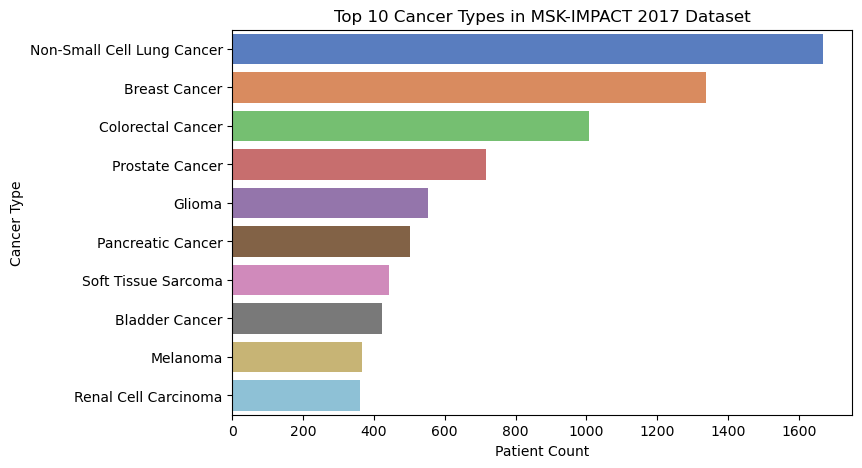

In [ ]:
plt.figure(figsize=(8, 5))

# Check top cancer types visually
sns.countplot(
    data=cancer_type_df,
    y="CANCER_TYPE",
    order=cancer_type_df["CANCER_TYPE"].value_counts().index,
    palette="muted",
)

plt.title('Top 10 Cancer Types in MSK-IMPACT 2017 Dataset')
plt.xlabel('Patient Count')
plt.ylabel('Cancer Type')
plt.show()

C:\Users\linds\AppData\Local\Temp\ipykernel_2224\4166329944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


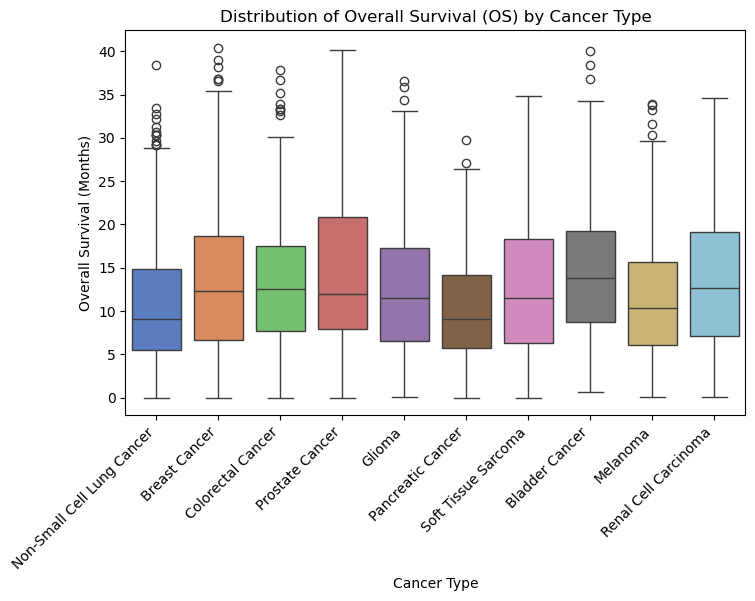

In [ ]:
plt.figure(figsize=(8, 5))

# Check distribution of OS by cancer type visually
sns.boxplot(
    data=cancer_type_df, 
    x='CANCER_TYPE', 
    y='OS_MONTHS', 
    order=cancer_type_df['CANCER_TYPE'].value_counts().head(10).index, # Keeps only the top 10 ordered by frequency
    palette='muted'
)

plt.title('Distribution of Overall Survival (OS) by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Overall Survival (Months)')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.show()

C:\Users\linds\AppData\Local\Temp\ipykernel_2224\1134559871.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


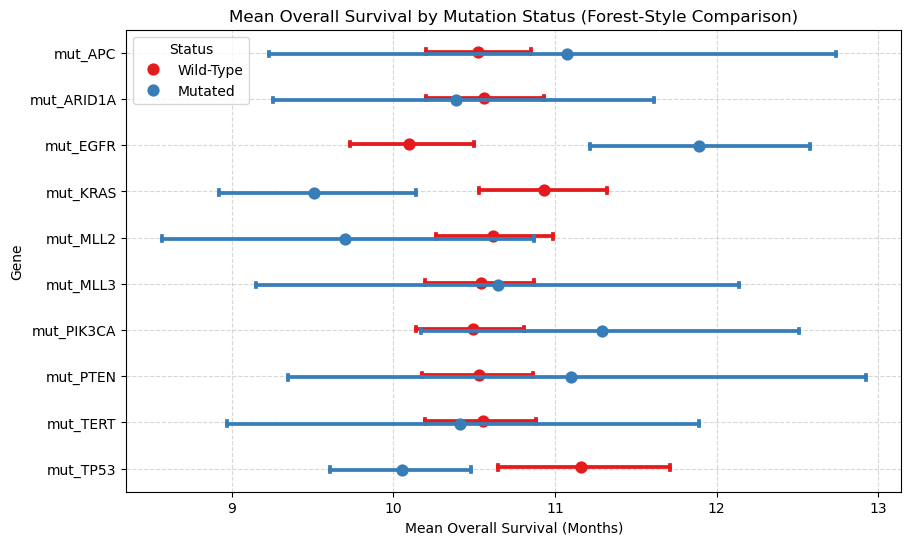

In [ ]:
# Filter for NSCLC
single_cancer_df = cancer_type_df[cancer_type_df['CANCER_TYPE'] == 'Non-Small Cell Lung Cancer'].copy()

# Melt mutation columns into a single 'Gene' and 'Status' column
#mutations_to_check = ['mut_TP53', 'mut_KRAS', 'mut_EGFR']
mutations_to_check = [col for col in single_cancer_df.columns if col.startswith("mut_")]

melted_df = pd.melt(
    single_cancer_df,
    id_vars=['OS_MONTHS'],                  
    value_vars= mutations_to_check,          
    var_name='Gene',                        
    value_name='Mutation_Status'
)

# Map 1/0 to readable labels
melted_df['Mutation_Status'] = melted_df['Mutation_Status'].map({1: 'Mutated', 0: 'Wild-Type', True: 'Mutated', False: 'Wild-Type'})

plt.figure(figsize=(10, 6))

sns.pointplot(
    data=melted_df,
    y='Gene',                 
    x='OS_MONTHS',            
    hue='Mutation_Status',    
    dodge=True,               
    join=False,               
    palette='Set1',
    capsize=0.1               
)

plt.title('Mean Overall Survival by Mutation Status')
plt.xlabel('Mean Overall Survival (Months)')
plt.ylabel('Gene')
plt.legend(title='Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [127]:
from lifelines import CoxPHFitter

ModuleNotFoundError: No module named 'lifelines'